In [ ]:
%pip install pandas matplotlib seaborn numpy networkx scikit-learn jupyter

### Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

# --- Configuration ---
INPUT_DIR = "final_output_cleaned"

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Define Color Palette for Experiments
# Green/Blue = Safe/Corporate, Orange/Red = Radical/Noisy, Purple = K8s
PALETTE = {
    'Pandas_ShortTerm': '#a8dadc',          # Light Blue
    'Pandas_LongTerm': '#457b9d',           # Strong Blue (Baseline)
    'Pandas_Prompt_A_Individual': '#1d3557',# Dark Blue (Precision)
    'Pandas_Prompt_B_Radical': '#e63946',   # Red (High Recall/Noise)
    'K8s_Artificial_Dense': '#9b5de5',      # Purple
    'K8s_Strict_Large': '#f15bb5',          # Pink
    'K8s_Mini_Strict': '#00bbf9'            # Cyan (The manual fix)
}

# --- Load Data ---
df_go = pd.read_csv(f"{INPUT_DIR}/growth_opportunities.csv")
df_str = pd.read_csv(f"{INPUT_DIR}/strengths.csv")
df_scores = pd.read_csv(f"{INPUT_DIR}/feedback_scores.csv")

# --- MANUAL FIX: Remap the "Lost" K8s GO ---
# The script found it in 'very last' folder which defaulted to Pandas. 
# We move it to its own category for accurate plotting.
mask = df_go['title'].str.contains("Avoid premature assignment", na=False)
df_go.loc[mask, 'test_id'] = 'K8s_Mini_Strict'

# Check loaded data
print(f"Loaded {len(df_go)} Growth Opportunities")
print(f"Loaded {len(df_str)} Strengths")
print(f"Loaded {len(df_scores)} Feedback Scores")

Loaded 536 Growth Opportunities
Loaded 1185 Strengths
Loaded 3318 Feedback Scores


### Total Signal Volume (Bar Chart)

C:\Users\Ethan\AppData\Local\Temp\ipykernel_44048\3671278684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=go_counts, x='test_id', y='count', palette=PALETTE)


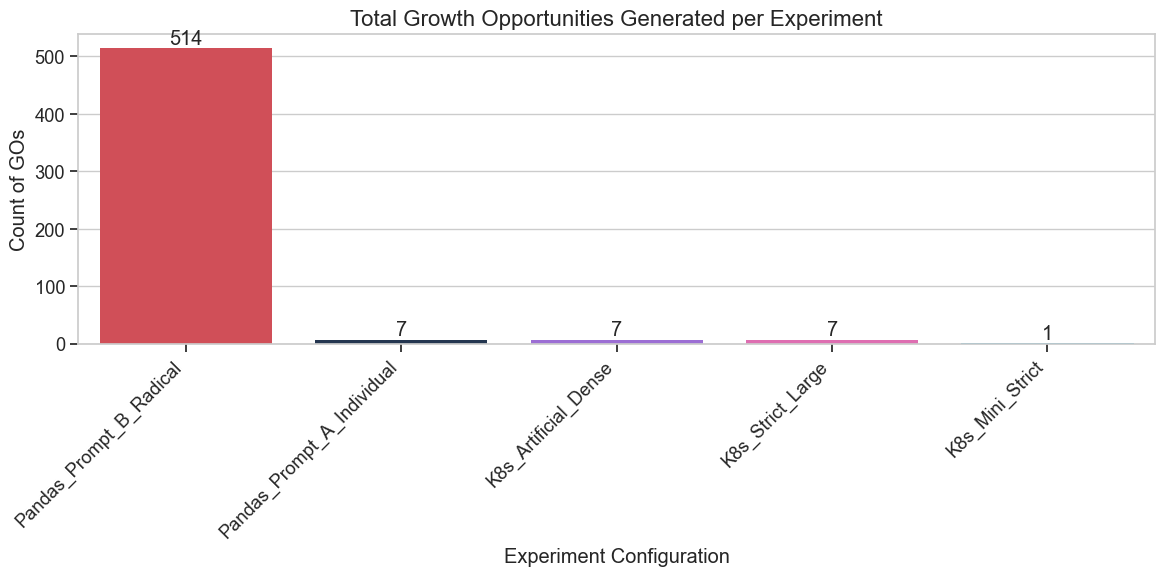

In [2]:
# Aggregate counts
go_counts = df_go['test_id'].value_counts().reset_index()
go_counts.columns = ['test_id', 'count']

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=go_counts, x='test_id', y='count', palette=PALETTE)

plt.title("Total Growth Opportunities Generated per Experiment", fontsize=16)
plt.xlabel("Experiment Configuration")
plt.ylabel("Count of GOs")
plt.xticks(rotation=45, ha='right')

# Add labels
for i in ax.containers:
    ax.bar_label(i,)

plt.tight_layout()
plt.show()

### Sentiment Distribution (Box Plot)

C:\Users\Ethan\AppData\Local\Temp\ipykernel_44048\3859181291.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scores, x='test_id', y='sentiment_score', order=order, palette=PALETTE)


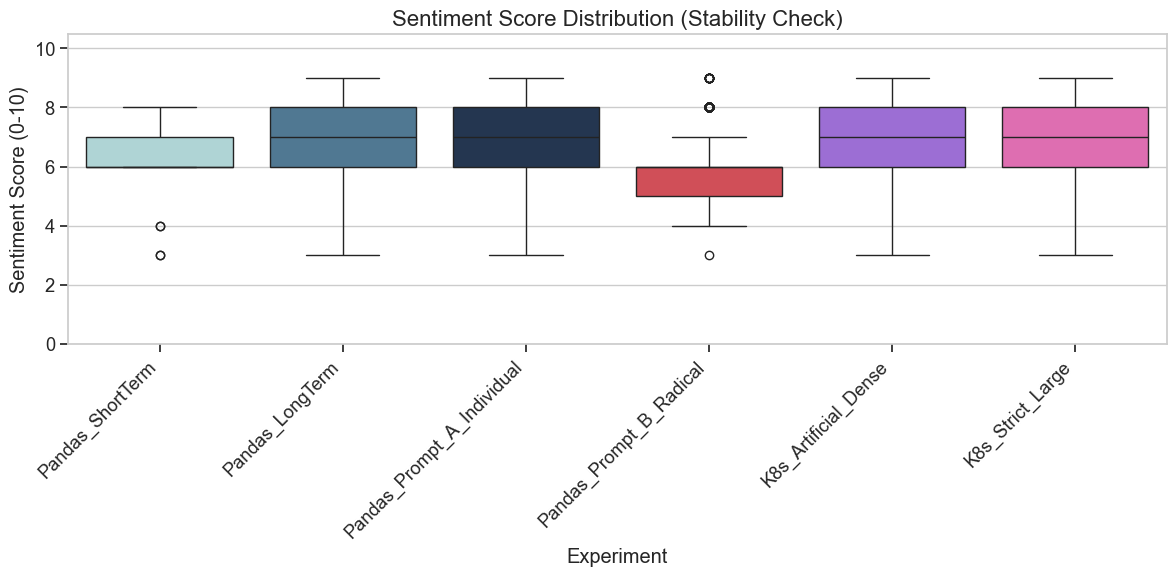

In [3]:
plt.figure(figsize=(12, 6))

# Order the plots logically
order = ['Pandas_ShortTerm', 'Pandas_LongTerm', 'Pandas_Prompt_A_Individual', 
         'Pandas_Prompt_B_Radical', 'K8s_Artificial_Dense', 'K8s_Strict_Large']

sns.boxplot(data=df_scores, x='test_id', y='sentiment_score', order=order, palette=PALETTE)

plt.title("Sentiment Score Distribution (Stability Check)", fontsize=16)
plt.ylabel("Sentiment Score (0-10)")
plt.xlabel("Experiment")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 10.5)

plt.tight_layout()
plt.show()

### Signal-to-Noise Ratio (Scatter Plot)

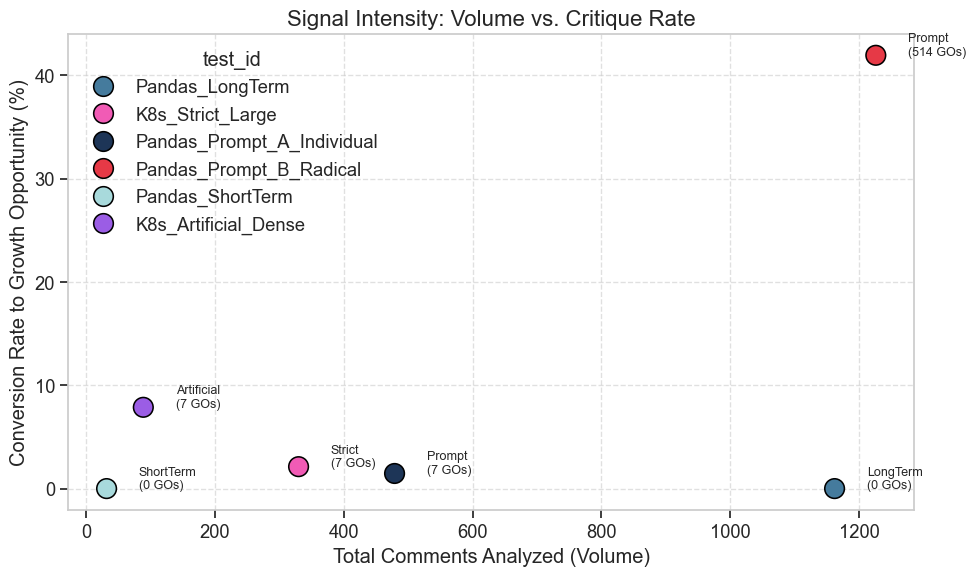

In [4]:
# Calculate metrics per test
metrics = []

for test in df_scores['test_id'].unique():
    n_go = len(df_go[df_go['test_id'] == test])
    n_str = len(df_str[df_str['test_id'] == test])
    n_total = len(df_scores[df_scores['test_id'] == test])
    
    if n_total == 0: continue
    
    # "Critique Rate" = % of comments that resulted in a Growth Opportunity
    critique_rate = (n_go / n_total) * 100
    
    metrics.append({
        'test_id': test,
        'critique_rate': critique_rate,
        'total_volume': n_total,
        'go_count': n_go
    })

df_metrics = pd.DataFrame(metrics)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_metrics, x='total_volume', y='critique_rate', 
                hue='test_id', palette=PALETTE, s=200, edgecolor='black')

plt.title("Signal Intensity: Volume vs. Critique Rate", fontsize=16)
plt.xlabel("Total Comments Analyzed (Volume)")
plt.ylabel("Conversion Rate to Growth Opportunity (%)")
plt.grid(True, linestyle='--', alpha=0.6)

# Label points
for i, row in df_metrics.iterrows():
    plt.text(row['total_volume']+50, row['critique_rate'], 
             f"{row['test_id'].split('_')[1]}\n({int(row['go_count'])} GOs)", 
             fontsize=9)

plt.tight_layout()
plt.show()

### Network Graph (The "Artificial Team")

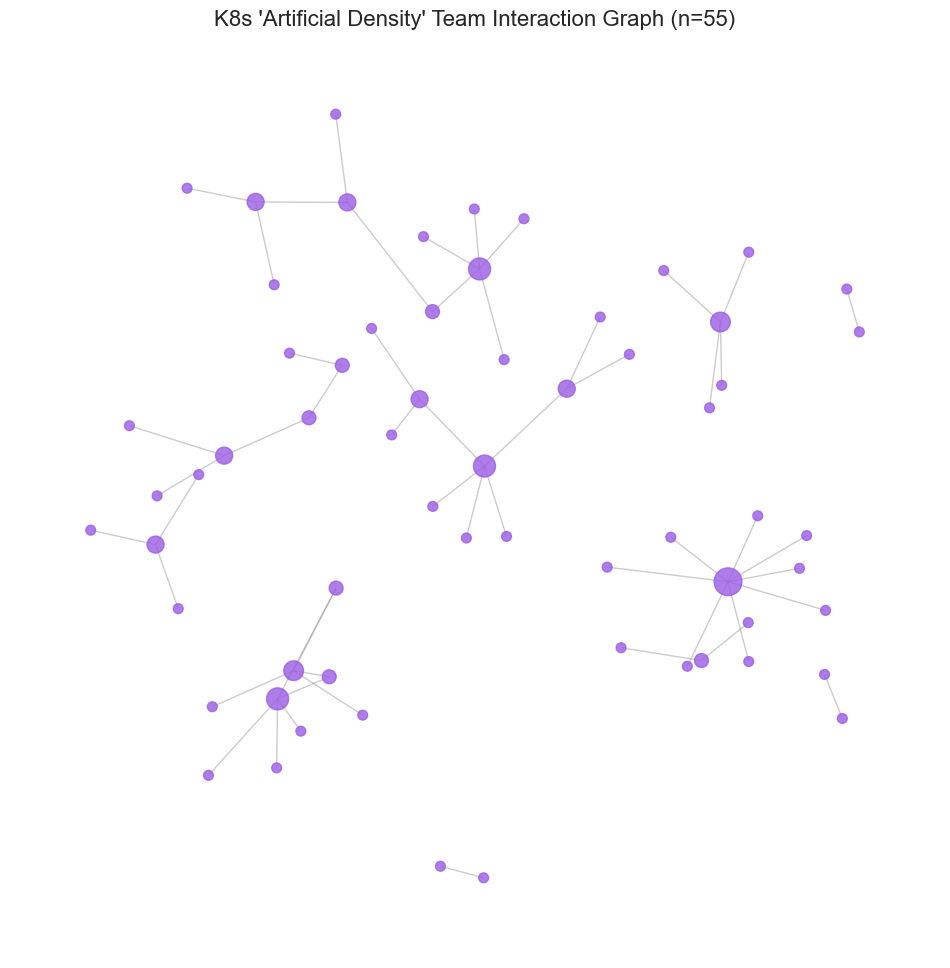

In [20]:
# Filter for K8s Artificial Dense run
k8s_data = df_scores[df_scores['test_id'] == 'K8s_Artificial_Dense']

# Create Graph
G = nx.from_pandas_edgelist(k8s_data, 'sender_email', 'recipient_email')

plt.figure(figsize=(12, 12))

# Calculate layout
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Draw nodes (size by degree/activity)
degrees = dict(G.degree())
node_sizes = [v * 50 for v in degrees.values()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=PALETTE['K8s_Artificial_Dense'], alpha=0.8)

# Draw edges (transparency represents interaction volume, but here just simple lines)
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

plt.title("K8s 'Artificial Density' Team Interaction Graph (n=55)", fontsize=16)
plt.axis('off')
plt.show()

### Top Insights Table (The "Hall of Fame")

In [24]:
from IPython.display import display, HTML

# Select random samples from each test to show variety
samples = []

for test in ['Pandas_Prompt_A_Individual', 'Pandas_Prompt_B_Radical', 'K8s_Strict_Large', 'K8s_Mini_Strict']:
    subset = df_go[df_go['test_id'] == test]
    
    if len(subset) > 0:
        # Get up to 3 random examples
        n = min(3, len(subset))
        random_picks = subset.sample(n)[['test_id', 'title', 'content']]
        samples.append(random_picks)

if samples:
    df_samples = pd.concat(samples)
    
    # Truncate long content for display
    df_samples['content'] = df_samples['content'].str.slice(0, 150) + "..."
    
    display(HTML("<h3>Selected Growth Opportunities by Experiment</h3>"))
    display(df_samples)
else:
    print("No samples found.")

,test_id,title,content
7,Pandas_Prompt_A_Individual,Provide complete and reproducible examples,Thanks for the report. Can you provide a fully...
6,Pandas_Prompt_A_Individual,Provide complete and reproducible examples,Closing as needs info. Can you post an example...
2,Pandas_Prompt_A_Individual,Avoid force-pushing after reviews,> [aram-cinnamon](https://github.com/aram-cinn...
27,Pandas_Prompt_B_Radical,Ensure alignment with project goals,I am not super optimistic about having to debu...
314,Pandas_Prompt_B_Radical,Enhance testing and benchmarking practices,Does anyone know any tricks to isolating what ...
315,Pandas_Prompt_B_Radical,Enhance testing and benchmarking practices,Yep will try to take a look in the next few da...
532,K8s_Strict_Large,Enhance debugging and testing practices,"@msau42 with regards to csi-attacher sidecar, ..."
535,K8s_Strict_Large,Improve code freeze awareness,@saad-ali should this issue be tracked for 1.1...
529,K8s_Strict_Large,Optimize API usage for scalability,Looking through [csi_plugin.go](https://github...
0,K8s_Mini_Strict,Avoid premature assignment of approvers,@ylink-lfs please stop assigning to approvers ...


### Pareto Analysis (Bias Check)

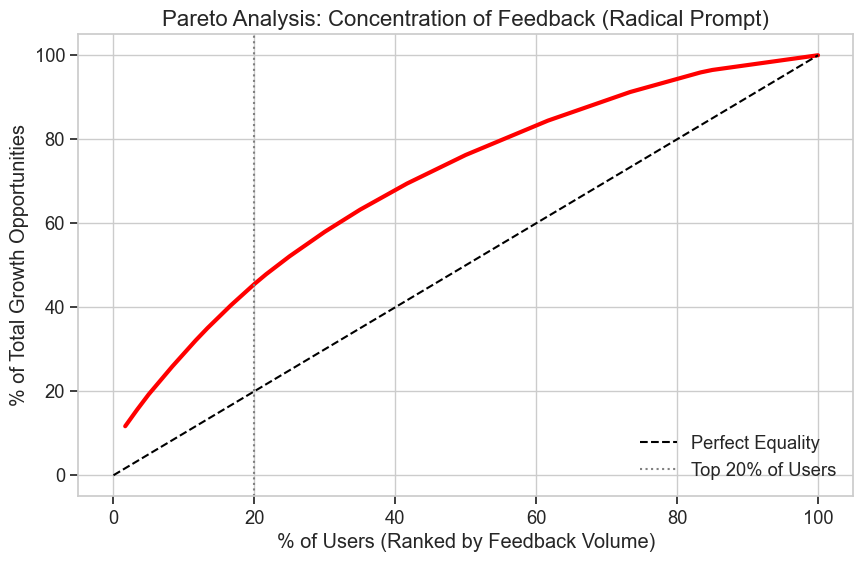

In [25]:
# Filter for Radical run
radical_df = df_go[df_go['test_id'] == 'Pandas_Prompt_B_Radical']

if not radical_df.empty:
    # Count GOs per user
    user_counts = radical_df['email'].value_counts().reset_index()
    user_counts.columns = ['email', 'go_count']
    
    # Calculate Cumulative %
    user_counts['cumulative_go'] = user_counts['go_count'].cumsum()
    user_counts['cumulative_perc'] = user_counts['cumulative_go'] / user_counts['go_count'].sum() * 100
    user_counts['user_rank'] = range(1, len(user_counts) + 1)
    user_counts['user_perc'] = user_counts['user_rank'] / len(user_counts) * 100

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=user_counts, x='user_perc', y='cumulative_perc', color='red', linewidth=3)
    
    # Reference Line (Perfect Equality)
    plt.plot([0, 100], [0, 100], 'k--', label="Perfect Equality")
    
    # 80/20 Rule Line
    plt.axvline(x=20, color='grey', linestyle=':', label="Top 20% of Users")
    
    plt.title("Pareto Analysis: Concentration of Feedback (Radical Prompt)", fontsize=16)
    plt.xlabel("% of Users (Ranked by Feedback Volume)")
    plt.ylabel("% of Total Growth Opportunities")
    plt.legend()
    plt.grid(True)
    plt.show()

### Sentiment vs. Content Length (Bias Check)

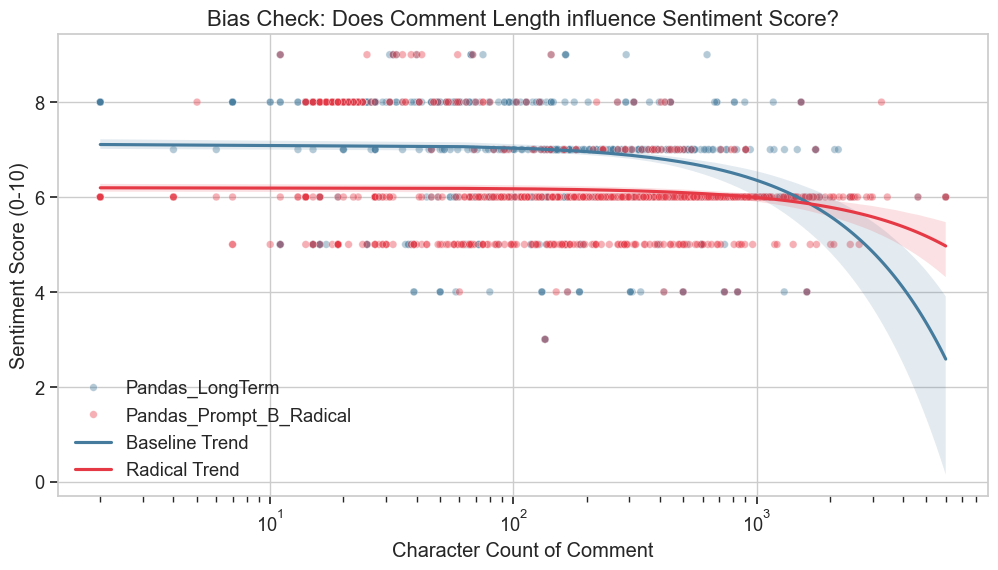

In [28]:
# Calculate content length
df_scores['content_length'] = df_scores['content'].str.len()

plt.figure(figsize=(12, 6))

# Filter for the main comparison (Pandas runs) to keep plot clean
subset = df_scores[df_scores['test_id'].isin(['Pandas_LongTerm', 'Pandas_Prompt_B_Radical'])]

sns.scatterplot(
    data=subset, 
    x='content_length', 
    y='sentiment_score', 
    hue='test_id', 
    palette=PALETTE,
    alpha=0.4,
    s=30
)

# Add trendlines
sns.regplot(data=subset[subset['test_id']=='Pandas_LongTerm'], x='content_length', y='sentiment_score', scatter=False, color=PALETTE['Pandas_LongTerm'], label='Baseline Trend')
sns.regplot(data=subset[subset['test_id']=='Pandas_Prompt_B_Radical'], x='content_length', y='sentiment_score', scatter=False, color=PALETTE['Pandas_Prompt_B_Radical'], label='Radical Trend')

plt.title("Bias Check: Does Comment Length influence Sentiment Score?", fontsize=16)
plt.xlabel("Character Count of Comment")
plt.ylabel("Sentiment Score (0-10)")
plt.xscale('log') # Log scale because some comments are massive
plt.legend()
plt.show()

### The "Grumpiness Delta" (Direct Comparison)

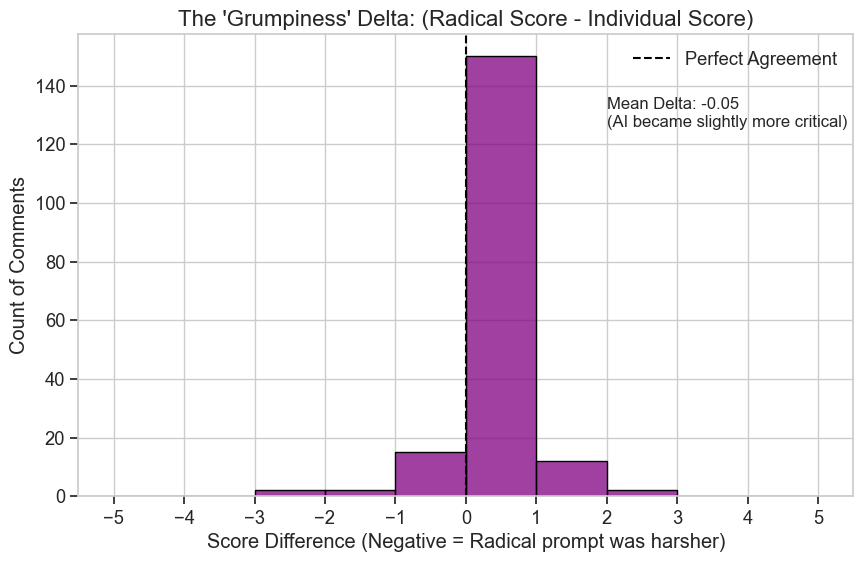

In [29]:
# 1. Pivot data to align Seed 4 and Seed 5 on the exact same content
pivot = df_scores.pivot_table(
    index='content', 
    columns='test_id', 
    values='sentiment_score', 
    aggfunc='first'
)

# Check if we have overlap
if 'Pandas_Prompt_A_Individual' in pivot.columns and 'Pandas_Prompt_B_Radical' in pivot.columns:
    
    # Calculate Delta (Radical - Individual)
    pivot['delta'] = pivot['Pandas_Prompt_B_Radical'] - pivot['Pandas_Prompt_A_Individual']
    
    # Filter for non-NaN
    comparison = pivot.dropna(subset=['delta'])
    
    plt.figure(figsize=(10, 6))
    
    sns.histplot(comparison['delta'], bins=range(-5, 6), kde=False, color='purple')
    
    plt.title("The 'Grumpiness' Delta: (Radical Score - Individual Score)", fontsize=16)
    plt.xlabel("Score Difference (Negative = Radical prompt was harsher)")
    plt.ylabel("Count of Comments")
    plt.xticks(range(-5, 6))
    plt.axvline(x=0, color='black', linestyle='--', label="Perfect Agreement")
    plt.legend()
    
    # Annotate
    mean_delta = comparison['delta'].mean()
    plt.text(2, plt.ylim()[1]*0.8, f"Mean Delta: {mean_delta:.2f}\n(AI became slightly more critical)", fontsize=12)
    
    plt.show()
else:
    print("Not enough overlap between Seed 4 and Seed 5 for a direct delta comparison.")

### Top Triggers (N-Grams)

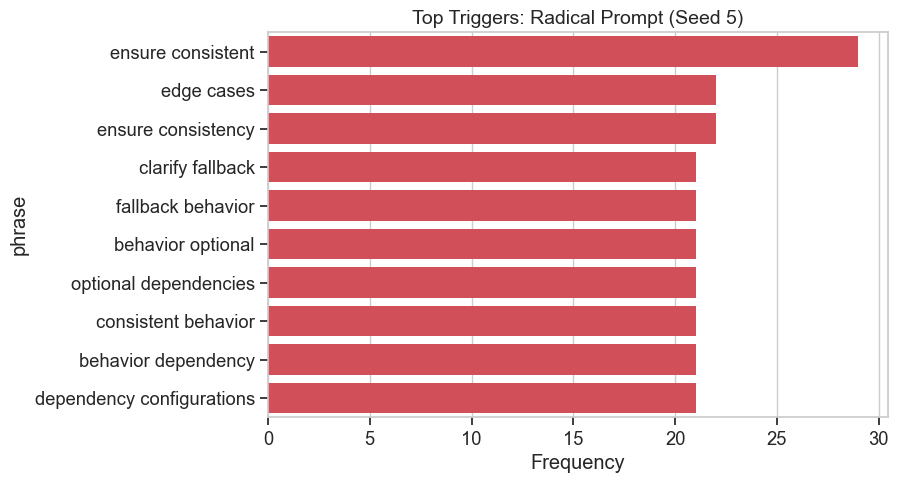

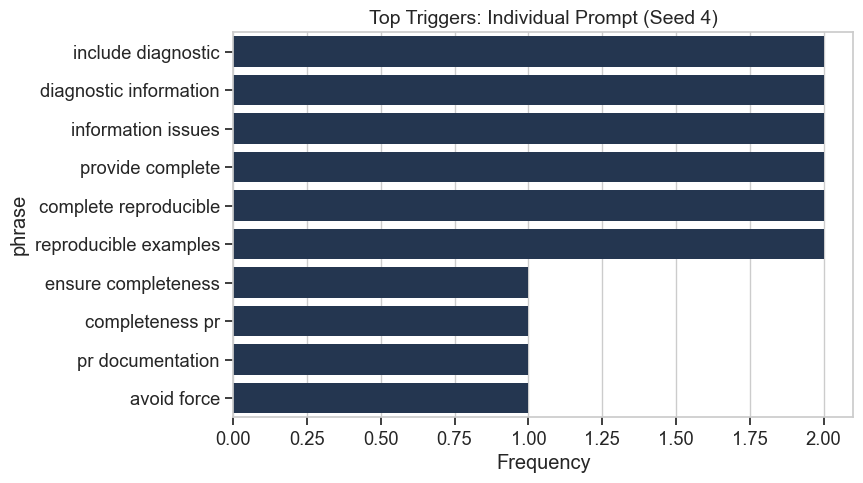

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(text_series, title, color, n=2):
    if text_series.empty: return
    
    # Use standard english stopwords
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:10]
    
    # Plot
    df_ngram = pd.DataFrame(words_freq, columns=['phrase', 'count'])
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_ngram, y='phrase', x='count', color=color)
    plt.title(title, fontsize=14)
    plt.xlabel("Frequency")
    plt.show()

# Compare Radical (Seed 5) vs Individual (Seed 4)
plot_top_ngrams(
    df_go[df_go['test_id'] == 'Pandas_Prompt_B_Radical']['title'], 
    "Top Triggers: Radical Prompt (Seed 5)", 
    PALETTE['Pandas_Prompt_B_Radical']
)

plot_top_ngrams(
    df_go[df_go['test_id'] == 'Pandas_Prompt_A_Individual']['title'], 
    "Top Triggers: Individual Prompt (Seed 4)", 
    PALETTE['Pandas_Prompt_A_Individual']
)

### Generate Drill-Down Report

In [31]:
html_content = """
<html>
<head>
<title>CollabSense Drill-Down</title>
<link rel="stylesheet" href="https://cdn.datatables.net/1.13.4/css/jquery.dataTables.min.css">
<script src="https://code.jquery.com/jquery-3.6.0.min.js"></script>
<script src="https://cdn.datatables.net/1.13.4/js/jquery.dataTables.min.js"></script>
<style>body { font-family: sans-serif; padding: 20px; } tr { font-size: 12px; }</style>
</head>
<body>
<h1>Growth Opportunities Drill-Down</h1>
<table id="goTable" class="display" style="width:100%">
    <thead>
        <tr>
            <th>Test ID</th>
            <th>Email</th>
            <th>Title</th>
            <th>Score</th>
            <th>Evidence Snippet</th>
            <th>Link</th>
        </tr>
    </thead>
    <tbody>
"""

# Iterate and fill table
for index, row in df_go.iterrows():
    snippet = str(row['content'])[:100].replace('"', '&quot;') + "..."
    link_html = f"<a href='{row['link']}' target='_blank'>View</a>"
    
    html_content += f"""
        <tr>
            <td>{row['test_id']}</td>
            <td>{row['email']}</td>
            <td>{row['title']}</td>
            <td>{row['sentiment_score']}</td>
            <td title="{str(row['content']).replace('"', '&quot;')}">{snippet}</td>
            <td>{link_html}</td>
        </tr>
    """

html_content += """
    </tbody>
</table>
<script>
    $(document).ready(function () {
        $('#goTable').DataTable({
            pageLength: 25
        });
    });
</script>
</body>
</html>
"""

# Save to file
with open(f"{INPUT_DIR}/drilldown_report.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Generated HTML report at: {INPUT_DIR}/drilldown_report.html")

Generated HTML report at: final_output_cleaned/drilldown_report.html
